In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Function to plot metrics
def plot_metric(y_values, ylabel, title):
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, y_values, marker='o')
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.show()
def plot_trainNval_metric(y_values_train, y_values_val, ylabel, title):
    plt.figure(figsize=(5, 3))
    plt.plot(epochs, y_values_train, marker='o', label="train")
    plt.plot(epochs, y_values_val, marker='o', label="val")
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()
def plot_trainNvalNtest_metric(y_values_train, y_values_val, y_values_test, ylabel, title):
    plt.figure(figsize=(5, 3))
    plt.plot(epochs, y_values_train, marker='o', label="train")
    plt.plot(epochs, y_values_val, marker='o', label="val")
    plt.plot(epochs, y_values_test, marker='o', label="test")
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [3]:
def get_metrics(file, metrics):
    epochs = []
    with open(log_file, 'r') as f:
        for line in f:
            entry = json.loads(line.strip())  # Parse each line as JSON
            epochs.append(entry['epoch'])
            metrics['train_loss'].append(entry['train_loss'])
            metrics['val_loss'].append(entry['val_loss'])
            metrics['test_loss'].append(entry['test_loss'])
            metrics['train_class_acc'].append(entry['train_class_acc'])
            metrics['val_accuracy'].append(entry['val_accuracy'])
            metrics['test_accuracy'].append(entry['test_accuracy'])
            metrics['val_roc_auc'].append(entry['val_roc_auc'])
            metrics['test_roc_auc'].append(entry['test_roc_auc'])
            metrics['test_balanced_accuracy'].append(entry['test_balanced_accuracy'])
            metrics['test_auc_pr'].append(entry['test_pr_auc'])
    return metrics, epochs
    

In [31]:
def plot_loss_acc_result(log_file, classifier_name, channel_size):
    metrics = {
        'train_loss': [], 'val_loss': [], 'test_loss': [],
        'train_class_acc': [], 'val_accuracy': [], 'test_accuracy': [],
        'val_roc_auc': [], 'test_roc_auc': [], 'test_balanced_accuracy':[],
        'test_auc_pr':[]
    }

    metrics, epochs = get_metrics(log_file, metrics)

    epoch_id = np.argmax(metrics['val_accuracy'])
    print(f"max val acc: {max(metrics['val_accuracy'])}, epoch is {epoch_id}")
    print(f"test balanced acc in epoch {epoch_id}: {metrics['test_balanced_accuracy'][epoch_id]}")
    print('---')
    epoch_id = np.argmax(metrics['test_balanced_accuracy'])
    print(f"max test balanced acc: {max(metrics['test_balanced_accuracy'])}, epoch is {epoch_id}")

    plot_trainNvalNtest_metric(metrics['train_class_acc'], metrics['val_accuracy'], metrics['test_balanced_accuracy'], 'Acc', f'Acc of Labram with {classifier_name} ({channel_size} chan)')
    plot_trainNvalNtest_metric(metrics['train_loss'], metrics['val_loss'], metrics['test_loss'], 'Loss', f'Loss of Labram with {classifier_name} ({channel_size} chan')

max val acc: 0.8438228438228438, epoch is 4
test balanced acc in epoch 4: 0.6797279446895815
---
max test balanced acc: 0.7915010820381665, epoch is 10


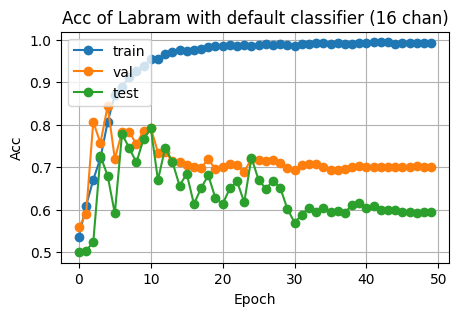

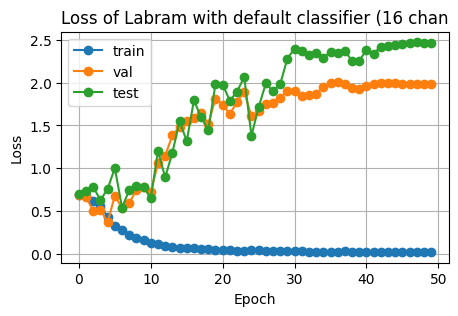

In [32]:
channel_size = 16
log_file = f'../checkpoints/finetune_stress_noleak_{channel_size}chan_no400up_seed_siwen42-4review-default/log.txt'
plot_loss_acc_result(log_file, classifier_name='default classifier', channel_size=channel_size)

max val acc: 0.8519813519813519, epoch is 1
test balanced acc in epoch 1: 0.5691548860346815
---
max test balanced acc: 0.7259632950170034, epoch is 10


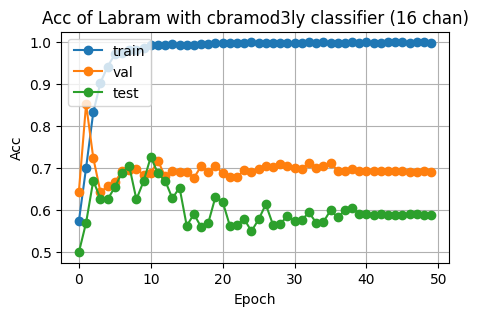

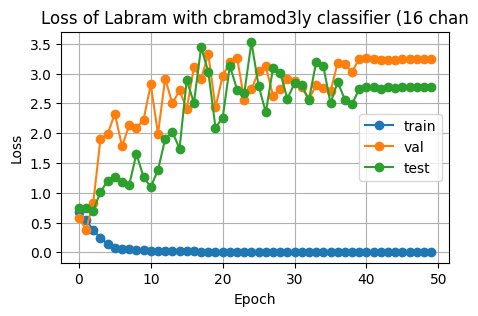

In [33]:
channel_size = 16
log_file = f'../checkpoints/finetune_stress_noleak_{channel_size}chan_no400up_seed_siwen42-4review-cbramod3lyclassifier/log.txt'
plot_loss_acc_result(log_file, classifier_name='cbramod3ly classifier', channel_size=channel_size)

max val acc: 0.9020979020979021, epoch is 5
test balanced acc in epoch 5: 0.9165003794159805
---
max test balanced acc: 0.9165003794159805, epoch is 5


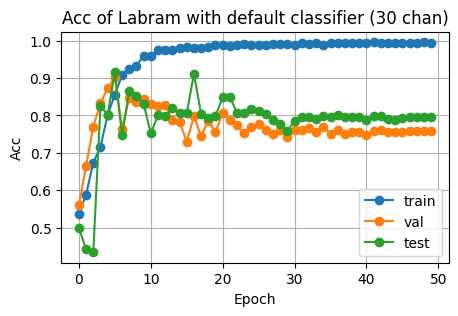

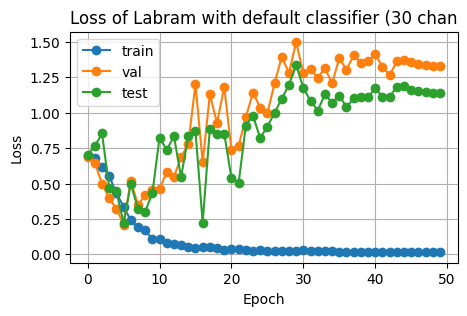

In [34]:
channel_size = 30
log_file = f'../checkpoints/finetune_stress_noleak_{channel_size}chan_no400up_seed_siwen42-4review-default/log.txt'
plot_loss_acc_result(log_file, classifier_name='default classifier', channel_size=channel_size)

max val acc: 0.8578088578088578, epoch is 4
test balanced acc in epoch 4: 0.8764396728591102
---
max test balanced acc: 0.8764396728591102, epoch is 4


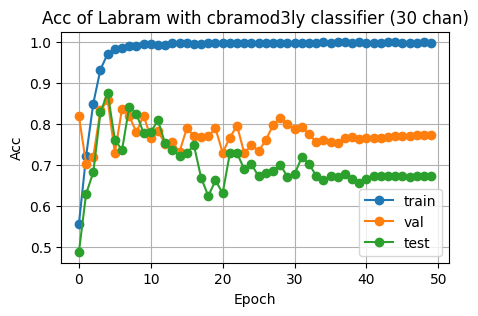

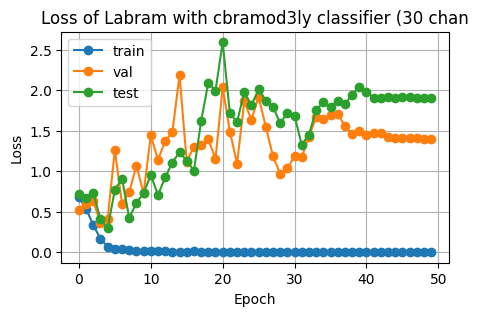

In [35]:
channel_size = 30
log_file = f'../checkpoints/finetune_stress_noleak_{channel_size}chan_no400up_seed_siwen42-4review-cbramod3lyclassifier/log.txt'
plot_loss_acc_result(log_file, classifier_name='cbramod3ly classifier', channel_size=channel_size)